In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Data Cleaning & Imports

In [64]:
data = pd.read_csv("data/cafc.csv")
french=['Type de plainte reçue', 
        'Pays',
        'Type de plainte reçue',
        'Pays',
        'Catégories thématiques sur la fraude et la cybercriminalité',
        'Méthode de sollicitation',
        'Genre',
        'Langue de correspondance',
        'Province/État',
        'Type de plainte']

col_rename = {
"Numéro d'identification / Number ID":"ID",
'Date Received / Date reçue':"Date",
"Fraud and Cybercrime Thematic Categories":"Category",
"Victim Age Range / Tranche d'âge des victimes":"Age",
"Number of Victims / Nombre de victimes":"Victim Count",
"Dollar Loss /pertes financières":"Dollar Loss",
"Province/State":"Province"
}

# Change Items to English & correct value types
data = data.drop(columns = french)
data.rename(columns = col_rename, inplace=True)
data = data[data["Dollar Loss"] != "$0.00"]
data["Dollar Loss"] = data["Dollar Loss"].replace('[\$,]', '', regex=True).astype(float)
data = data.replace(["Not Specified","Not Available", "'Not Available / non disponible"], np.nan)


# Filter to Canada Only
data = data[data["Country"]=="Canada"]

data.head()

<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:27: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_7436/703660975.py:27: SyntaxWarning: invalid escape sequence '\$'
  data["Dollar Loss"] = data["Dollar Loss"].replace('[\$,]', '', regex=True).astype(float)


,ID,Date,Complaint Received Type,Country,Province,Category,Solicitation Method,Gender,Language of Correspondence,Age,Complaint Type,Victim Count,Dollar Loss
5,350313,2025-09-29,Phone,Canada,Alberta,Investments,Internet,Male,English,'70 - 79,Victim,1,20000.00
9,350317,2025-09-29,Phone,Canada,Quebec,Service,Internet,NaN,French,'20 - 29,Victim,1,596.67
14,350322,2025-09-29,Phone,Canada,Quebec,Service,Internet-social network,Male,French,'50 - 59,Victim,1,599.01
15,350323,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,4649.05
19,350327,2025-09-29,Phone,Canada,Quebec,Spear Phishing,Email,NaN,French,NaN,Victim,1,50294.82


## Data Exploration & Adjustments

If we have fewer than around 100 observations we'll be removing them. Same for the "Unknown" and "Other" Categories

In [85]:
category_drops = ["Unknown","Other","Vacation","Charity / Donation","Psychics","Unauthorized Charge","Incomplete","Credit Card","Collection Agency","Health","Directory","Survey","Telecom Fraud","Spoofing","Fraudulent Cheque"]
data = data[~data["Category"].isin(category_drops)]

solicit_drop = ["Mail","Television","Video Call","Print","Radio"]
data = data[~data["Solicitation Method"].isin(solicit_drop)]

In [88]:
data["Dollar Loss"].describe().apply(lambda x: format(x, 'f'))

count       56667.000000
mean        35095.109010
std        199201.623878
min             0.010000
25%           433.050000
50%          2500.000000
75%         15714.640000
max      18599009.700000
Name: Dollar Loss, dtype: object

In [66]:
data.shape[0]

58494

# Plots

### Provinces

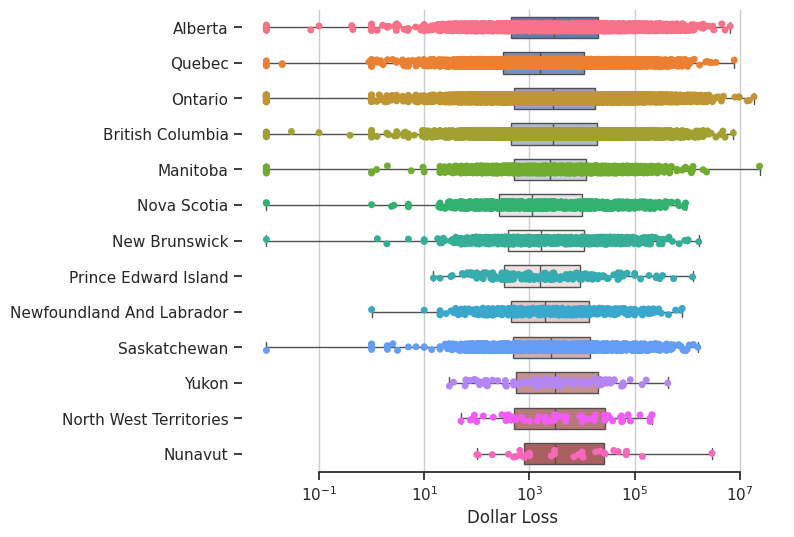

In [76]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7,6))
ax.set_xscale("log")
sns.boxplot(
    data, x="Dollar Loss", y="Province", hue="Province",
    whis=[0,100], width=.6,palette="vlag"
)

sns.stripplot(data,x="Dollar Loss", y="Province", hue="Province")

plt.legend([],[], frameon=False)
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True,left=True)

### Category

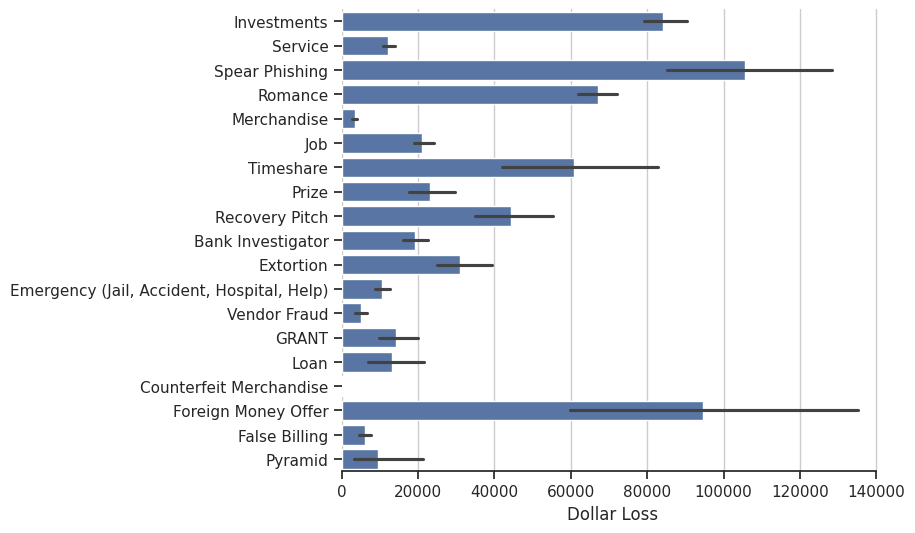

In [96]:
sns.set_theme(style="ticks")
f, ax = plt.subplots(figsize=(7,6))
sns.barplot(
    data, x="Dollar Loss", y="Category", label = "Total", color="b")

plt.legend([],[], frameon=False)
ax.xaxis.grid(True)
ax.set(ylabel="")
sns.despine(trim=True,left=True)